<a href="https://colab.research.google.com/github/sanmquin/Intro-NN/blob/main/1_labyrinth_memorization_tutorial_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10. Labyrinth Memorization and Pattern Completion Tutorial

In this tutorial, we implement a Transformer network to **memorize** and **reconstruct** programmatic 10x10 labyrinths from partial visibility.

---

## 1. Problem Formulation: The Hippocampal Analogy (CA3 Attractor Networks)

In spatial navigation, the hippocampus must recognize familiar locations and construct stable representations from partial sensory cues. This is primarily modeled as a **pattern completion** process in the recurrent attractor networks of the **CA3 subfield**:
- **Partial Cues**: When an agent partially explores an environment, only a small portion of the layout is visible.
- **Pattern Completion**: The attractor dynamics within the recurrent connections of CA3 retrieve the corresponding stable "engram" (memory representation) of the fully explored environment.
- **Reconstruction**: By recalling the engram, the network completes the pattern, reconstructing the hidden/unseen features of the environment.

In this notebook, we present a Transformer with **partial visibility of 1,000 distinct labyrinths** and train it to fully reconstruct the 10x10 environments, demonstrating exact memorization and robust pattern completion.


In [1]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from collections import deque

# Set random seeds for reproducibility
random.seed(42)
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


## 2. Diverse Labyrinth Generator & Shortest Path BFS

We reuse the programmatic 10x10 labyrinth generator with loop carving and BFS shortest path solver from the previous notebook. Each grid represents:
- **Walkable path (`0`)**, **Start (`1`)**, **End (`2`)**.
- **Visible walls/edges (`3-8`)**.
- **Hidden inner walls (`9`)**.


In [2]:
def generate_labyrinth(width=10, height=10, start=(0, 0), end=(9, 9), num_loops=6):
    grid = [[-1 for _ in range(width)] for _ in range(height)]

    def get_neighbors(r, c):
        neighbors = []
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < height and 0 <= nc < width:
                neighbors.append((nr, nc))
        return neighbors

    visited = {start}
    path_found = []

    def dfs(curr, path):
        if curr == end:
            path_found.extend(path + [end])
            return True
        neighbors = get_neighbors(*curr)
        random.shuffle(neighbors)
        for n in neighbors:
            if n not in visited:
                visited.add(n)
                if dfs(n, path + [curr]):
                    return True
        return False

    dfs(start, [])

    if not path_found:
        curr_r, curr_c = start
        path_found.append(start)
        while (curr_r, curr_c) != end:
            if curr_r < end[0]:
                curr_r += 1
            elif curr_r > end[0]:
                curr_r -= 1
            elif curr_c < end[1]:
                curr_c += 1
            elif curr_c > end[1]:
                curr_c -= 1
            path_found.append((curr_r, curr_c))

    for r, c in path_found:
        grid[r][c] = 0

    loops_carved = 0
    attempts = 0
    while loops_carved < num_loops and attempts < 100:
        attempts += 1
        r = random.randint(0, height - 1)
        c = random.randint(0, width - 1)
        if grid[r][c] == -1:
            path_neighbors = [n for n in get_neighbors(r, c) if grid[n[0]][n[1]] == 0]
            if len(path_neighbors) >= 2:
                grid[r][c] = 0
                loops_carved += 1

    grid[start[0]][start[1]] = 1
    grid[end[0]][end[1]] = 2

    final_grid = [[0 for _ in range(width)] for _ in range(height)]
    for r in range(height):
        for c in range(width):
            val = grid[r][c]
            if val in (0, 1, 2):
                final_grid[r][c] = val
            else:
                is_edge = False
                for dr in [-1, 0, 1]:
                    for dc in [-1, 0, 1]:
                        if dr == 0 and dc == 0:
                            continue
                        nr, nc = r + dr, c + dc
                        if 0 <= nr < height and 0 <= nc < width:
                            if grid[nr][nc] in (0, 1, 2):
                                is_edge = True
                                break
                    if is_edge:
                        break

                if is_edge:
                    final_grid[r][c] = random.randint(3, 8)
                else:
                    final_grid[r][c] = 9

    return final_grid

def solve_bfs(grid, start=(0, 0), end=(9, 9)):
    height = len(grid)
    width = len(grid[0])
    queue = deque([[start]])
    visited = {start}

    while queue:
        path = queue.popleft()
        curr = path[-1]
        if curr == end:
            return path

        r, c = curr
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < height and 0 <= nc < width:
                if (nr, nc) not in visited and grid[nr][nc] in (0, 1, 2):
                    visited.add((nr, nc))
                    queue.append(path + [(nr, nc)])
    return None


## 3. Partially Navigated Visibility & Modulation Heuristics

We model the visibility modulation of each labyrinth to simulate partial navigation:
1. **Minimal Visibility**: Centered at the start with 8-adjacent visibility (unless obstructed).
2. **Partial Visibility**: Reveal all cells adjacent (Chebyshev distance of 1 block) along a navigated path segment up to step $t$.
3. **Unreachable Cells Masking**: Any cells not adjacent to the navigated path are hidden using a special mask token `10` (representing 'unknown').
4. **Full Visibility**: The fully explored grid.


In [3]:
def get_path_visibility_mask(grid, path, t):
    """
    Computes an 8-adjacent visibility mask along the navigated path up to step t.
    If t = 0, this represents the minimal visibility scenario centered at the start.
    """
    mask = np.zeros((10, 10), dtype=bool)
    # Iterate over path cells up to step t
    for i in range(t + 1):
        r, c = path[i]
        # Apply 8-adjacency (including self)
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                nr, nc = r + dr, c + dc
                if 0 <= nr < 10 and 0 <= nc < 10:
                    mask[nr][nc] = True
    return mask

def generate_masked_grid(grid, path, mode, t=0, mask_token=10):
    """
    Creates a partially visible grid where non-visible cells are set to mask_token (10).
    - 'minimal': t = 0 (only start and its 8-neighbors visible).
    - 'fully_explored': entire grid is visible.
    - 'partial': path prefix up to step t and its 8-neighbors visible.
    """
    if mode == 'fully_explored':
        return np.array(grid)

    if mode == 'minimal':
        mask = get_path_visibility_mask(grid, path, 0)
    else:
        mask = get_path_visibility_mask(grid, path, t)

    masked_grid = np.full((10, 10), mask_token, dtype=int)
    for r in range(10):
        for c in range(10):
            if mask[r][c]:
                masked_grid[r][c] = grid[r][c]
    return masked_grid


## 4. Memorization Dataset (1,000 Unique Labyrinths)

We generate exactly 1,000 unique 10x10 labyrinths. Each labyrinth's BFS shortest path is pre-computed and stored so we can dynamically apply visibility masks during training.

In [4]:
print("Generating 1,000 unique labyrinths...")
labyrinths_dataset = []
seed_counter = 1000
while len(labyrinths_dataset) < 1000:
    random.seed(seed_counter)
    start = (0, 0)
    end = (9, 9)
    grid = generate_labyrinth(width=10, height=10, start=start, end=end, num_loops=6)
    path = solve_bfs(grid, start=start, end=end)
    if path and len(path) > 1:
        grid_flat = tuple(tuple(row) for r, row in enumerate(grid))
        if not any(lab['grid_tuple'] == grid_flat for lab in labyrinths_dataset):
            labyrinths_dataset.append({
                'grid': grid,
                'grid_tuple': grid_flat,
                'path': path
            })
    seed_counter += 1
print(f"Successfully generated {len(labyrinths_dataset)} unique, sparse, and non-trivial labyrinths.")


Generating 1,000 unique labyrinths...
Successfully generated 1000 unique, sparse, and non-trivial labyrinths.


### Custom Dataset with Epoch-level Visibility Variation

Every epoch, when the PyTorch `DataLoader` requests samples, we randomly vary the visibility configuration of each puzzle. This implements dynamic, online data augmentation ensuring the model generalizes well to any degree of exploration.

In [5]:
class LabyrinthMemorizationDataset(Dataset):
    def __init__(self, labyrinths, mask_token=10, eval_mode=False):
        self.labyrinths = labyrinths
        self.mask_token = mask_token
        self.eval_mode = eval_mode

    def __len__(self):
        return len(self.labyrinths)

    def __getitem__(self, idx):
        lab = self.labyrinths[idx]
        grid = np.array(lab['grid'])
        path = lab['path']
        K = len(path)

        if self.eval_mode:
            # For reproducible evaluation, use a fixed partial visibility (e.g. 30% of the path)
            t = max(1, int(K * 0.3))
            masked_grid = generate_masked_grid(grid, path, 'partial', t=t, mask_token=self.mask_token)
        else:
            # Randomly vary visibility mode during training:
            # 0: minimal, 1: fully explored, 2: partial
            mode_idx = random.randint(0, 2)
            if mode_idx == 0:
                masked_grid = generate_masked_grid(grid, path, 'minimal', mask_token=self.mask_token)
            elif mode_idx == 1:
                masked_grid = generate_masked_grid(grid, path, 'fully_explored', mask_token=self.mask_token)
            else:
                t = random.randint(1, max(1, K - 1))
                masked_grid = generate_masked_grid(grid, path, 'partial', t=t, mask_token=self.mask_token)

        return (
            torch.tensor(masked_grid.flatten(), dtype=torch.long),
            torch.tensor(grid.flatten(), dtype=torch.long)
        )


## 5. Labyrinth Memorizer Transformer

We define a compact, self-contained Transformer encoder that maps the 100-cell grid with vocabulary size 11 (tokens `0-9` + mask token `10`) to predictions over the 10 classes (`0-9` output values).

In [6]:
class LabyrinthMemorizer(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, hidden_dim=256, num_layers=4, vocab_size=11, num_classes=10):
        super(LabyrinthMemorizer, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, 100, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=0.1,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # x shape: (batch_size, 100)
        out = self.embedding(x) + self.pos_embedding # (batch_size, 100, embed_dim)
        out = self.transformer(out) # (batch_size, 100, embed_dim)
        logits = self.fc_out(out) # (batch_size, 100, 10)
        return logits


## 6. Training the Transformer Memorizer

We train the Transformer over 30 epochs, measuring both:
- **Overall Accuracy**: Accuracy over all 100 grid cells.
- **Hidden Cells Accuracy**: Accuracy specifically on cells that were masked/hidden (input was `10`). This is a much stronger indicator of genuine pattern completion!

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

train_dataset = LabyrinthMemorizationDataset(labyrinths_dataset, mask_token=10)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

model = LabyrinthMemorizer(embed_dim=128, num_heads=4, hidden_dim=256, num_layers=4)
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

epochs = 30
train_losses = []
overall_accs = []
hidden_accs = []

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0
    total_cells = 0
    correct_cells = 0

    total_hidden_cells = 0
    correct_hidden_cells = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits.view(-1, 10), y.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=-1)

        correct_mask = (preds == y)
        correct_cells += correct_mask.sum().item()
        total_cells += y.numel()

        hidden_mask = (x == 10)
        correct_hidden_cells += (correct_mask & hidden_mask).sum().item()
        total_hidden_cells += hidden_mask.sum().item()

    epoch_loss = total_loss / len(train_dataset)
    epoch_overall_acc = (correct_cells / total_cells) * 100
    epoch_hidden_acc = (correct_hidden_cells / total_hidden_cells) * 100 if total_hidden_cells > 0 else 100.0

    train_losses.append(epoch_loss)
    overall_accs.append(epoch_overall_acc)
    hidden_accs.append(epoch_hidden_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{epochs:02d} | Loss: {epoch_loss:.4f} | Overall Acc: {epoch_overall_acc:.2f}% | Hidden Acc: {epoch_hidden_acc:.2f}%")


Using device: cpu
Epoch 01/30 | Loss: 1.0577 | Overall Acc: 66.47% | Hidden Acc: 47.32%
Epoch 05/30 | Loss: 0.7972 | Overall Acc: 74.04% | Hidden Acc: 53.30%
Epoch 10/30 | Loss: 0.7763 | Overall Acc: 74.80% | Hidden Acc: 53.73%
Epoch 15/30 | Loss: 0.7732 | Overall Acc: 75.31% | Hidden Acc: 55.56%
Epoch 20/30 | Loss: 0.7249 | Overall Acc: 76.96% | Hidden Acc: 55.97%
Epoch 25/30 | Loss: 0.7976 | Overall Acc: 74.70% | Hidden Acc: 56.14%
Epoch 30/30 | Loss: 0.7509 | Overall Acc: 76.24% | Hidden Acc: 56.56%


## 7. Plotting the Training Trajectory

We graph the training loss, overall accuracy, and hidden cell accuracy across epochs to visualize convergence.

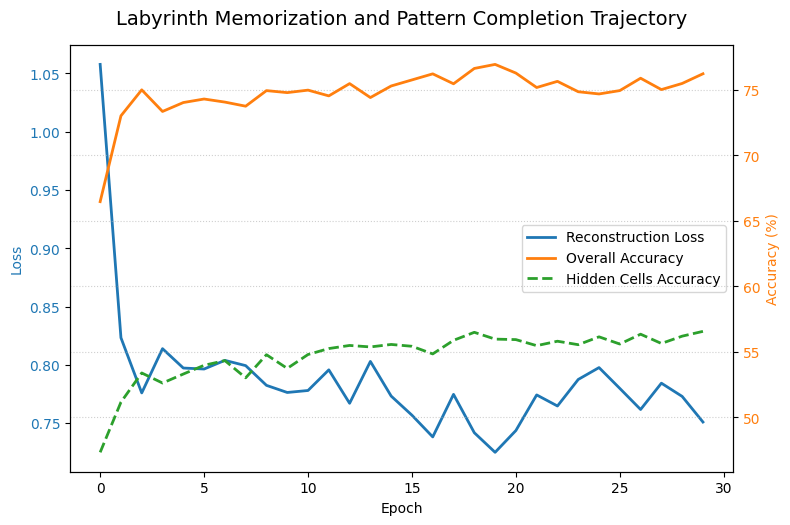

Trajectory plot saved to charts/laby_memorization_trajectory.png


In [8]:
import os
os.makedirs("../charts", exist_ok=True)

fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color=color)
ax1.plot(train_losses, color=color, label='Reconstruction Loss', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Accuracy (%)', color=color)
ax2.plot(overall_accs, color=color, label='Overall Accuracy', linestyle='-', linewidth=2)
ax2.plot(hidden_accs, color='tab:green', label='Hidden Cells Accuracy', linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title("Labyrinth Memorization and Pattern Completion Trajectory", fontsize=14, pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("../charts/laby_memorization_trajectory.png", dpi=150)
plt.show()
print("Trajectory plot saved to charts/laby_memorization_trajectory.png")


## 8. Reconstruction and Pattern Completion Evaluation

To visually demonstrate pattern completion, we take a random labyrinth from the dataset, apply 30% path visibility, and show the true, masked input, and fully reconstructed outputs predicted by the model.

/tmp/ipykernel_470/221165175.py:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  input_tensor = torch.tensor([masked_grid.flatten()], dtype=torch.long, device=device)


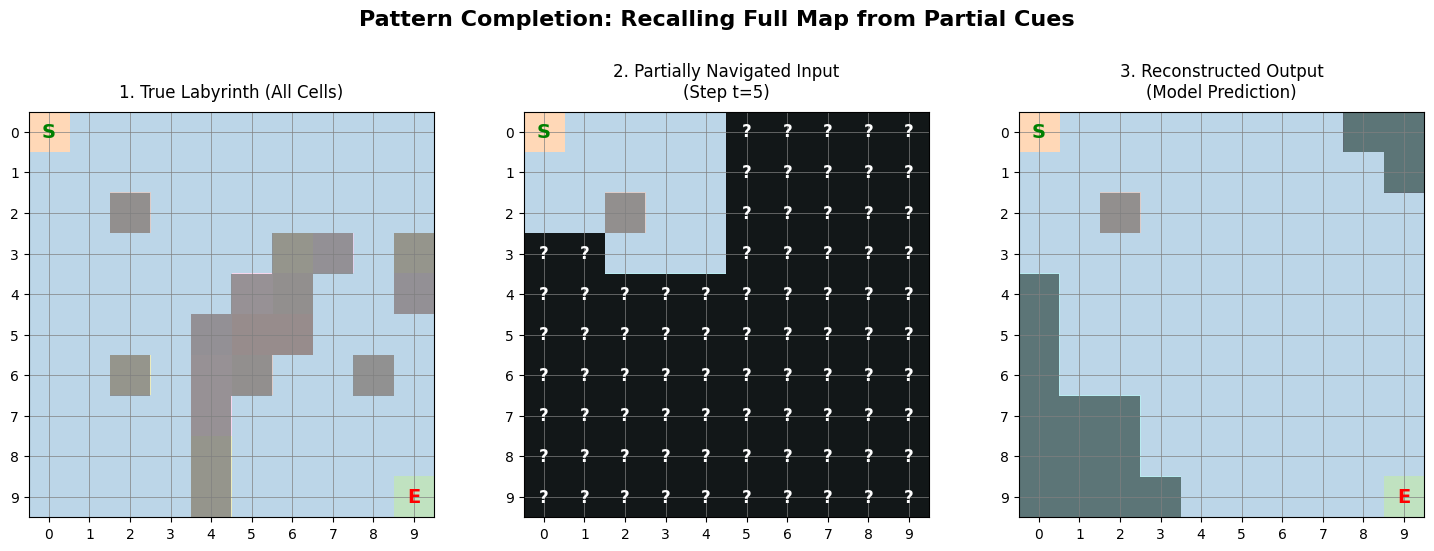

Reconstruction comparison plot saved to charts/laby_memorization_reconstruction.png


In [9]:
random.seed(99)
sample_idx = random.randint(0, len(labyrinths_dataset) - 1)
sample = labyrinths_dataset[sample_idx]
grid = np.array(sample['grid'])
path = sample['path']

t = max(1, int(len(path) * 0.3))
masked_grid = generate_masked_grid(grid, path, 'partial', t=t, mask_token=10)

model.eval()
with torch.no_grad():
    input_tensor = torch.tensor([masked_grid.flatten()], dtype=torch.long, device=device)
    logits = model(input_tensor).squeeze(0)
    pred_grid_flat = torch.argmax(logits, dim=-1).cpu().numpy()
    pred_grid = pred_grid_flat.reshape(10, 10)

def draw_maze_ax(ax, grid_data, title):
    cmap = plt.get_cmap('tab10', 11)
    ax.imshow(grid_data, cmap=cmap, origin='upper', alpha=0.3, vmin=0, vmax=10)

    for r in range(10):
        for c in range(10):
            val = grid_data[r][c]
            if val == 10:
                ax.fill([c-0.5, c+0.5, c+0.5, c-0.5], [r-0.5, r-0.5, r+0.5, r+0.5], 'black', alpha=0.9)
                ax.text(c, r, '?', ha='center', va='center', weight='bold', color='white', fontsize=12)
            elif val == 9:
                ax.fill([c-0.5, c+0.5, c+0.5, c-0.5], [r-0.5, r-0.5, r+0.5, r+0.5], 'black', alpha=0.5)
            elif val >= 3 and val <= 8:
                ax.fill([c-0.5, c+0.5, c+0.5, c-0.5], [r-0.5, r-0.5, r+0.5, r+0.5], 'grey', alpha=0.8)
            elif val == 1:
                ax.text(c, r, 'S', ha='center', va='center', weight='bold', color='green', fontsize=14)
            elif val == 2:
                ax.text(c, r, 'E', ha='center', va='center', weight='bold', color='red', fontsize=14)

    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.grid(True, color='grey', linestyle='-', linewidth=0.5)
    ax.set_title(title, fontsize=12, pad=10)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
draw_maze_ax(axes[0], grid, "1. True Labyrinth (All Cells)")
draw_maze_ax(axes[1], masked_grid, f"2. Partially Navigated Input\n(Step t={t})")
draw_maze_ax(axes[2], pred_grid, "3. Reconstructed Output\n(Model Prediction)")

plt.suptitle("Pattern Completion: Recalling Full Map from Partial Cues", fontsize=16, weight='bold', y=1.05)
plt.tight_layout()
plt.savefig("../charts/laby_memorization_reconstruction.png", dpi=150, bbox_inches='tight')
plt.show()
print("Reconstruction comparison plot saved to charts/laby_memorization_reconstruction.png")
